In [17]:
import os

!apt-get update
!apt-get install -y libzbar0
!pip install pyzbar

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [1]:
import os

# 1. Install kagglehub
!pip install kagglehub

# 2. Set the environment variable for Kaggle authentication
os.environ["KAGGLE_API_TOKEN"] = "KGAT_10b1607853261a8f1c7220ef7329f071"

# 3. Save access token to ~/.kaggle/access_token
!mkdir -p ~/.kaggle && echo "KGAT_10b1607853261a8f1c7220ef7329f071" > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

print("Kaggle authentication successful!")

Kaggle authentication successful!


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jonathanimmanuel/barcode-and-qr")

print("Path to dataset files:", path)

100%|██████████| 226M/226M [00:02<00:00, 95.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jonathanimmanuel/barcode-and-qr/versions/8


In [3]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/jonathanimmanuel/barcode-and-qr/versions/8"

print("--- Root Contents ---")
subfolders = os.listdir(dataset_path)
print(subfolders)

print("\n--- Image Count Per Category ---")
for folder in subfolders:
    folder_full_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_full_path):
        images = [f for f in os.listdir(folder_full_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
        print(f"📁 {folder}: {len(images)} images")

--- Root Contents ---
['blurredimage015_jpg.rf.e7d91b6c245629051b88e1352ca83625.jpg', 'Foto(792).xml', 'glareimage028_jpg.rf.538e3bcfb04f942899bcde728209ab44.jpg', 'lotsimage003_jpg.rf.a6c50675815275326ead8861f5c8d752.jpg', '05102009103.jpg', 'Foto(535).xml', '05102009168.jpg', 'v2Email_png.rf.a953734638bf4c542f4b95f22e95eadb.jpg', 'Foto(800).xml', 'Foto(839).jpg', 'v3YouTube_png.rf.2b9af184600bebb1d60b0ccdacf3ce88.jpg', 'pathologicalimage005_png.rf.187470866a063be8de54dcedb4e6b600.xml', '05102009192.jpg', 'closeimage015_jpg.rf.5425ab633ecf782ad1a84fdcf2f3fcd6.xml', 'rotationsimage014_jpg.rf.23d3f506316316595f3fcf37936f4199.jpg', 'glareimage030_jpg.rf.dd3cc5d14fce44ecaa28dfc2cf0f88f3.jpg', '05102009151.xml', 'shadowsimage004_jpg.rf.20f934af281cf15df63ae98462932780.jpg', 'v3VCard-Type_png.rf.22385d6824401ca42feb8551327b9ae1.jpg', 'blurredimage040_jpg.rf.e18d94cf4bb20c8c895846260bb4822e.xml', 'Foto(555).jpg', 'glareimage045_jpg.rf.f46a05e4cd23ea133f2f5f0134fcc6b5.xml', 'noncompliantimage

In [4]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/jonathanimmanuel/barcode-and-qr/versions/8"

all_files = os.listdir(dataset_path)

# Filter images and annotations
image_extensions = ('.jpg', '.jpeg', '.png', '.bmp')
images = [f for f in all_files if f.lower().endswith(image_extensions)]
xmls = [f for f in all_files if f.lower().endswith('.xml')]
others = [f for f in all_files if not f.lower().endswith(image_extensions + ('.xml',))]

print(f" Total files: {len(all_files)}")
print(f" Images: {len(images)}")
print(f" XML Annotations: {len(xmls)}")
print(f" Other files: {len(others)}")

 Total files: 1904
 Images: 952
 XML Annotations: 952
 Other files: 0


In [5]:
import os
import shutil

dataset_path = "/root/.cache/kagglehub/datasets/jonathanimmanuel/barcode-and-qr/versions/8"
images_dir = os.path.join(dataset_path, "images")
labels_dir = os.path.join(dataset_path, "annotations")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

image_exts = ('.jpg', '.jpeg', '.png', '.bmp')

for filename in os.listdir(dataset_path):
    file_path = os.path.join(dataset_path, filename)

    # Skip directories we just created
    if os.path.isdir(file_path):
        continue

    if filename.lower().endswith(image_exts):
        shutil.move(file_path, os.path.join(images_dir, filename))
    elif filename.lower().endswith('.xml'):
        shutil.move(file_path, os.path.join(labels_dir, filename))

print(" Directory reorganization complete!")

 Directory reorganization complete!


In [6]:
import os
import xml.etree.ElementTree as ET
from collections import Counter

labels_dir = "/root/.cache/kagglehub/datasets/jonathanimmanuel/barcode-and-qr/versions/8/annotations"
class_counts = Counter()

for xml_file in os.listdir(labels_dir):
    if xml_file.endswith(".xml"):
        tree = ET.parse(os.path.join(labels_dir, xml_file))
        root = tree.getroot()

        for obj in root.findall("object"):
            class_name = obj.find("name").text
            class_counts[class_name] += 1

print("--- Bounding Box Counts per Class ---")
for cls, count in class_counts.items():
    print(f"🏷️ {cls}: {count} bounding boxes")

--- Bounding Box Counts per Class ---
🏷️ barcode: 498 bounding boxes
🏷️ qr: 1197 bounding boxes
🏷️ d: 1 bounding boxes


In [20]:
import os
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset, DataLoader

class BarcodeDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=416, S=13, B=1, C=2):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.S = S  # Grid size (13x13)
        self.B = B  # Bounding boxes per grid cell
        self.C = C  # Number of classes (0: Barcode, 1: QR Code)

        self.images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # 1. Load Image
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image.transpose((2, 0, 1)) / 255.0  # Normalize to [0, 1] & (C, H, W)

        # 2. Load Corresponding Target Labels
        label_path = os.path.join(self.label_dir, os.path.splitext(img_name)[0] + ".txt")

        # Target matrix shape: (S, S, C + 5*B)
        # 5 values per box: [x, y, w, h, confidence]
        target = torch.zeros((self.S, self.S, self.C + 5 * self.B))

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    class_id, x, y, w, h = [float(x) for x in line.replace("\n", "").split()]
                    class_id = int(class_id)

                    # Determine grid cell (i, j) where object center falls
                    i, j = int(self.S * y), int(self.S * x)
                    x_cell, y_cell = self.S * x - j, self.S * y - i

                    # Assign target if no object exists in cell yet
                    if target[i, j, self.C] == 0:
                        target[i, j, self.C] = 1  # Confidence
                        target[i, j, self.C + 1: self.C + 5] = torch.tensor([x_cell, y_cell, w, h])
                        target[i, j, class_id] = 1  # One-hot encoding for class

        return torch.tensor(image, dtype=torch.float32), target

# Test Dataset Setup
# dataset = BarcodeDataset(img_dir="path/to/images", label_dir="path/to/labels")
# train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [25]:
import torch.nn as nn

class YoloLoss(nn.Module):
    def __init__(self, S=13, B=1, C=2, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S = S
        self.B = B
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse = nn.MSELoss(reduction="sum")

    def forward(self, predictions, target):
        # Reshape predictions: (Batch, S, S, C + 5*B)
        predictions = predictions.permute(0, 2, 3, 1)

        # Masks for cells containing objects vs background
        exists_box = target[..., self.C:self.C+1]  # Shape: (Batch, S, S, 1)

        # 1. Bounding Box Coordinates Loss (x, y, w, h)
        # Extract x, y, w, h for predicted boxes
        pred_x = predictions[..., self.C + 1]
        pred_y = predictions[..., self.C + 2]
        pred_w = predictions[..., self.C + 3]
        pred_h = predictions[..., self.C + 4]

        # Extract x, y, w, h for target boxes
        target_x = target[..., self.C + 1]
        target_y = target[..., self.C + 2]
        target_w = target[..., self.C + 3]
        target_h = target[..., self.C + 4]

        # Apply square root transformation for w and h to create new tensors
        pred_w_transformed = torch.sign(pred_w) * torch.sqrt(torch.abs(pred_w + 1e-6))
        pred_h_transformed = torch.sign(pred_h) * torch.sqrt(torch.abs(pred_h + 1e-6))
        target_w_transformed = torch.sqrt(target_w)
        target_h_transformed = torch.sqrt(target_h)

        # Reconstruct the transformed box predictions and targets for coordinate loss
        # Stack them to get a shape like (Batch, S, S, 4)
        box_predictions_transformed = torch.stack(
            (pred_x, pred_y, pred_w_transformed, pred_h_transformed), dim=-1
        )
        box_targets_transformed = torch.stack(
            (target_x, target_y, target_w_transformed, target_h_transformed), dim=-1
        )

        coord_loss = self.mse(
            torch.flatten(exists_box * box_predictions_transformed, end_dim=-2),
            torch.flatten(exists_box * box_targets_transformed, end_dim=-2),
        )

        # 2. Object Confidence Loss (Cells with objects)
        pred_conf = predictions[..., self.C:self.C+1]
        target_conf = target[..., self.C:self.C+1]

        object_loss = self.mse(
            torch.flatten(exists_box * pred_conf),
            torch.flatten(exists_box * target_conf),
        )

        # 3. No-Object Confidence Loss (Background grid cells)
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * pred_conf),
            torch.flatten((1 - exists_box) * target_conf),
        )

        # 4. Classification Loss
        class_preds = predictions[..., :self.C]
        class_targets = target[..., :self.C]

        class_loss = self.mse(
            torch.flatten(exists_box * class_preds, end_dim=-2),
            torch.flatten(exists_box * class_targets, end_dim=-2),
        )

        total_loss = (
            self.lambda_coord * coord_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return total_loss

In [29]:
!apt-get install -y libzbar0
!pip install pyzbar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar0 is already the newest version (0.23.92-4build2).
0 upgraded, 0 newly installed, 0 to remove and 173 not upgraded.


In [36]:
!apt-get install -y libzbar0
!pip install pyzbar kagglehub opencv-python matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libzbar0 is already the newest version (0.23.92-4build2).
0 upgraded, 0 newly installed, 0 to remove and 173 not upgraded.


Using device: cuda
Using Colab cache for faster access to the 'barcode-and-qr' dataset.
Raw Dataset Cache Path: /kaggle/input/barcode-and-qr
Dataset copied to writable path: /content/barcode-qr-dataset
 Dataset successfully organized into 'images/' and 'labels/'!
🚀 Starting Training...
Epoch [1/20] | Mean Loss: 159.4510
Epoch [2/20] | Mean Loss: 75.9242
Epoch [3/20] | Mean Loss: 64.2508
Epoch [4/20] | Mean Loss: 47.1126
Epoch [5/20] | Mean Loss: 42.2372
Epoch [6/20] | Mean Loss: 33.2279
Epoch [7/20] | Mean Loss: 33.4487
Epoch [8/20] | Mean Loss: 26.3894
Epoch [9/20] | Mean Loss: 22.7602
Epoch [10/20] | Mean Loss: 18.8054
Epoch [11/20] | Mean Loss: 14.5534
Epoch [12/20] | Mean Loss: 12.2716
Epoch [13/20] | Mean Loss: 12.3834
Epoch [14/20] | Mean Loss: 10.4361
Epoch [15/20] | Mean Loss: 9.8948
Epoch [16/20] | Mean Loss: 8.5436
Epoch [17/20] | Mean Loss: 7.6700
Epoch [18/20] | Mean Loss: 6.6525
Epoch [19/20] | Mean Loss: 4.7670
Epoch [20/20] | Mean Loss: 4.1761
 Model weights saved to bar

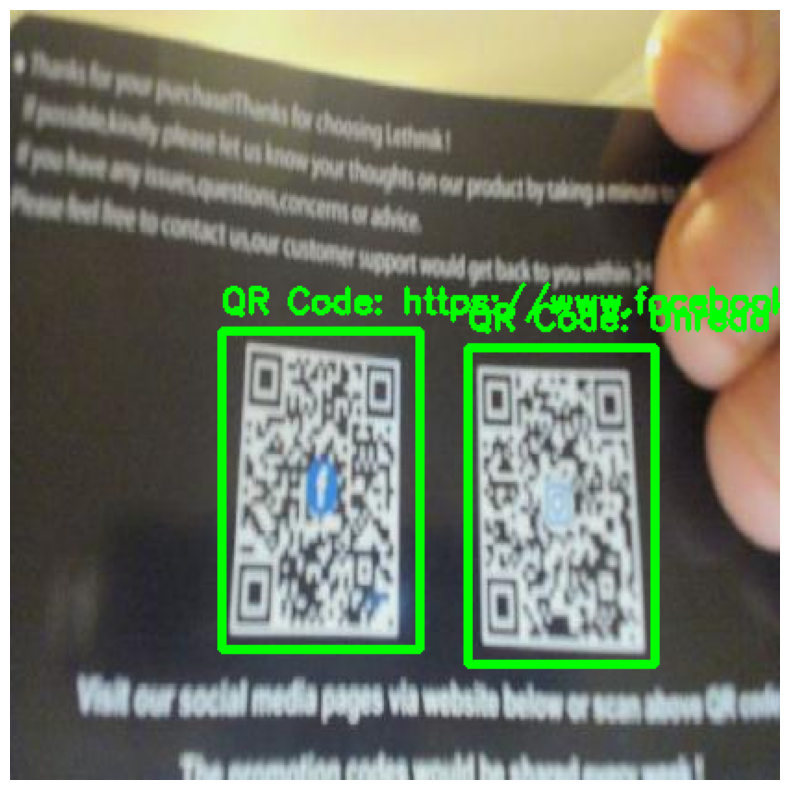

In [38]:
import os
import shutil
import xml.etree.ElementTree as ET
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from pyzbar.pyzbar import decode as pyzbar_decode
import kagglehub

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. DOWNLOAD & REORGANIZE DATASET
# ==========================================
# Download dataset to Kaggle cache path (read-only)
raw_dataset_cache_path = kagglehub.dataset_download("jonathanimmanuel/barcode-and-qr")
print("Raw Dataset Cache Path:", raw_dataset_cache_path)

# Define a writable path in /content/
writable_dataset_path = os.path.join("/content", "barcode-qr-dataset")

# Copy contents from read-only cache to writable path
if os.path.exists(writable_dataset_path):
    shutil.rmtree(writable_dataset_path)
shutil.copytree(raw_dataset_cache_path, writable_dataset_path)
print(f"Dataset copied to writable path: {writable_dataset_path}")

images_dir = os.path.join(writable_dataset_path, "images")
labels_dir = os.path.join(writable_dataset_path, "labels")

os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

# Class Mapping: 0 = Barcode, 1 = QR Code
CLASS_MAP = {"barcode": 0, "qrcode": 1, "qr_code": 1, "qr": 1}
CLASS_NAMES = {0: "Barcode", 1: "QR Code"}

image_exts = ('.jpg', '.jpeg', '.png', '.bmp')

# Separate files and convert XMLs to YOLO TXT format
for filename in os.listdir(writable_dataset_path):
    file_path = os.path.join(writable_dataset_path, filename)
    if os.path.isdir(file_path):
        continue

    if filename.lower().endswith(image_exts):
        shutil.move(file_path, os.path.join(images_dir, filename))
    elif filename.lower().endswith('.xml'):
        tree = ET.parse(file_path)
        root = tree.getroot()

        img_w = float(root.find('size/width').text)
        img_h = float(root.find('size/height').text)

        txt_filename = os.path.splitext(filename)[0] + '.txt'
        txt_path = os.path.join(labels_dir, txt_filename)

        with open(txt_path, 'w') as f:
            for obj in root.findall('object'):
                cls_name = obj.find('name').text.lower()
                if cls_name not in CLASS_MAP:
                    continue
                cls_id = CLASS_MAP[cls_name]

                bndbox = obj.find('bndbox')
                xmin = float(bndbox.find('xmin').text)
                ymin = float(bndbox.find('ymin').text)
                xmax = float(bndbox.find('xmax').text)
                ymax = float(bndbox.find('ymax').text)

                # Relative YOLO coordinates [0, 1]
                x_center = ((xmin + xmax) / 2.0) / img_w
                y_center = ((ymin + ymax) / 2.0) / img_h
                w = (xmax - xmin) / img_w
                h = (ymax - ymin) / img_h

                f.write(f"{cls_id} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")

print(" Dataset successfully organized into 'images/' and 'labels/'!")


# ==========================================
# 2. PYTORCH DATASET & DATALOADER
# ==========================================
class BarcodeDataset(Dataset):
    def __init__(self, img_dir, label_dir, img_size=416, S=13, C=2):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.img_size = img_size
        self.S = S
        self.C = C
        self.images = [f for f in os.listdir(img_dir) if f.lower().endswith(image_exts)]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_size, self.img_size))
        image = image.transpose((2, 0, 1)) / 255.0  # Normalize (3, 416, 416)

        label_path = os.path.join(self.label_dir, os.path.splitext(img_name)[0] + ".txt")
        target = torch.zeros((self.S, self.S, self.C + 5)) # [C0, C1, Conf, x, y, w, h]

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls_id, x, y, w, h = [float(val) for val in line.strip().split()]
                    cls_id = int(cls_id)

                    # Determine grid cell
                    i, j = int(self.S * y), int(self.S * x)
                    x_cell, y_cell = self.S * x - j, self.S * y - i

                    if target[i, j, self.C] == 0:
                        target[i, j, self.C] = 1.0  # Confidence
                        target[i, j, self.C + 1: self.C + 5] = torch.tensor([x_cell, y_cell, w, h])
                        target[i, j, cls_id] = 1.0   # Class

        return torch.tensor(image, dtype=torch.float32), target

dataset = BarcodeDataset(images_dir, labels_dir)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True, drop_last=True)


# ==========================================
# 3. CUSTOM CNN OBJECT DETECTOR
# ==========================================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_c)
        self.leaky = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.leaky(self.bn(self.conv(x)))

class CustomBarcodeDetector(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = nn.Sequential(
            ConvBlock(3, 32),
            nn.MaxPool2d(2, 2), # 208
            ConvBlock(32, 64),
            nn.MaxPool2d(2, 2), # 104
            ConvBlock(64, 128),
            ConvBlock(128, 64, kernel_size=1, padding=0),
            ConvBlock(64, 128),
            nn.MaxPool2d(2, 2), # 52
            ConvBlock(128, 256),
            ConvBlock(256, 128, kernel_size=1, padding=0),
            ConvBlock(128, 256),
            nn.MaxPool2d(2, 2), # 26
            ConvBlock(256, 512),
            ConvBlock(512, 256, kernel_size=1, padding=0),
            ConvBlock(256, 512),
            nn.MaxPool2d(2, 2), # 13
            ConvBlock(512, 1024),
            ConvBlock(1024, 512, kernel_size=1, padding=0),
            ConvBlock(512, 1024),
        )
        self.head = nn.Conv2d(1024, num_classes + 5, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.head(self.backbone(x))
        return self.sigmoid(out) # Keep all outputs strictly bounded in [0, 1]


# ==========================================
# 4. LOSS FUNCTION & TRAINING LOOP
# ==========================================
class YoloLoss(nn.Module):
    def __init__(self, S=13, C=2, lambda_coord=10.0, lambda_noobj=0.5):
        super().__init__()
        self.C = C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
        self.mse = nn.MSELoss(reduction="sum")

    def forward(self, predictions, target):
        predictions = predictions.permute(0, 2, 3, 1) # (Batch, S, S, C + 5)
        exists_box = target[..., self.C:self.C+1]     # Object present mask

        # Box Coordinates
        coord_loss = self.mse(
            torch.flatten(exists_box * predictions[..., self.C+1:self.C+5], end_dim=-2),
            torch.flatten(exists_box * target[..., self.C+1:self.C+5], end_dim=-2)
        )

        # Object Confidence
        object_loss = self.mse(
            torch.flatten(exists_box * predictions[..., self.C:self.C+1]),
            torch.flatten(exists_box * target[..., self.C:self.C+1])
        )

        # No Object Confidence
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., self.C:self.C+1]),
            torch.flatten((1 - exists_box) * target[..., self.C:self.C+1])
        )

        # Class Probability
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :self.C], end_dim=-2),
            torch.flatten(exists_box * target[..., :self.C], end_dim=-2)
        )

        return (self.lambda_coord * coord_loss) + object_loss + (self.lambda_noobj * no_object_loss) + class_loss

# Training Execution
model = CustomBarcodeDetector(num_classes=2).to(device)
criterion = YoloLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

EPOCHS = 20
print("🚀 Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Mean Loss: {total_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "barcode_detector.pth")
print(" Model weights saved to barcode_detector.pth")


# ==========================================
# 5. POST-PROCESSING: NMS & DECODING
# ==========================================
def iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = box1_area + box2_area - intersection + 1e-6
    return intersection / union

def non_max_suppression(bboxes, iou_thresh=0.3, conf_thresh=0.4):
    bboxes = [b for b in bboxes if b[1] > conf_thresh]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    nms_boxes = []

    while bboxes:
        chosen_box = bboxes.pop(0)
        nms_boxes.append(chosen_box)
        bboxes = [
            b for b in bboxes
            if b[0] != chosen_box[0] or iou(chosen_box[2:], b[2:]) < iou_thresh
        ]
    return nms_boxes

def decode_predictions(predictions, S=13, C=2, img_shape=(416, 416)):
    orig_w, orig_h = img_shape
    predictions = predictions.squeeze(0).permute(1, 2, 0)

    boxes = []
    for i in range(S):
        for j in range(S):
            conf = predictions[i, j, C].item()
            if conf > 0.3:
                x_cell = predictions[i, j, C + 1].item()
                y_cell = predictions[i, j, C + 2].item()
                w = predictions[i, j, C + 3].item()
                h = predictions[i, j, C + 4].item()

                x_center = (j + x_cell) / S
                y_center = (i + y_cell) / S

                x1 = int((x_center - w / 2.0) * orig_w)
                y1 = int((y_center - h / 2.0) * orig_h)
                x2 = int((x_center + w / 2.0) * orig_w)
                y2 = int((y_center + h / 2.0) * orig_h)

                # Clamp to image frame boundaries
                x1, y1 = max(0, min(orig_w, x1)), max(0, min(orig_h, y1))
                x2, y2 = max(0, min(orig_w, x2)), max(0, min(orig_h, y2))

                class_id = torch.argmax(predictions[i, j, :C]).item()
                boxes.append([class_id, conf, x1, y1, x2, y2])

    return boxes

def robust_barcode_decoder(cropped_roi):
    """ Tries direct decoding, thresholding, and slight rotations for tilted barcodes """
    if cropped_roi.size == 0:
        return "Unread"

    gray = cv2.cvtColor(cropped_roi, cv2.COLOR_BGR2GRAY)

    # 1. Standard decode
    decoded = pyzbar_decode(gray)
    if decoded:
        return decoded[0].data.decode('utf-8')

    # 2. Adaptive threshold
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    decoded = pyzbar_decode(thresh)
    if decoded:
        return decoded[0].data.decode('utf-8')

    # 3. Rotation decoding (-15, 15, -30, 30 deg)
    (h, w) = gray.shape[:2]
    center = (w // 2, h // 2)
    for angle in [-15, 15, -30, 30]:
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(gray, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
        decoded = pyzbar_decode(rotated)
        if decoded:
            return decoded[0].data.decode('utf-8')

    return "Unread"


# ==========================================
# 6. INFERENCE & COLAB VISUALIZATION
# ==========================================
def run_test(image_path, model, device):
    model.eval()
    raw_img = cv2.imread(image_path)
    if raw_img is None:
        print("Image not found!")
        return

    orig_h, orig_w, _ = raw_img.shape
    resized_img = cv2.resize(raw_img, (416, 416))
    tensor_img = torch.tensor(resized_img, dtype=torch.float32).permute(2, 0, 1) / 255.0
    input_tensor = tensor_img.unsqueeze(0).to(device)

    with torch.no_grad():
        preds = model(input_tensor)

    raw_boxes = decode_predictions(preds.cpu(), img_shape=(orig_w, orig_h))
    final_boxes = non_max_suppression(raw_boxes, iou_thresh=0.3, conf_thresh=0.4)

    annotated = raw_img.copy()
    print(f"\n Found {len(final_boxes)} detection(s):")

    for idx, (cls_id, conf, x1, y1, x2, y2) in enumerate(final_boxes):
        cls_name = CLASS_NAMES.get(cls_id, "Unknown")

        # Crop region and decode content
        roi = raw_img[y1:y2, x1:x2]
        payload = robust_barcode_decoder(roi)

        print(f" [{idx+1}] {cls_name} ({conf:.2f}) -> Data: {payload}")

        color = (0, 255, 0) if cls_id == 1 else (255, 0, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 3)
        cv2.putText(annotated, f"{cls_name}: {payload}", (x1, max(20, y1 - 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Plot output in Colab
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# Run inference on a sample image from dataset
sample_image = os.path.join(images_dir, os.listdir(images_dir)[0])
run_test(sample_image, model, device)


 Found 1 detection(s):
 [1] QR Code (0.96) -> Data: Unread


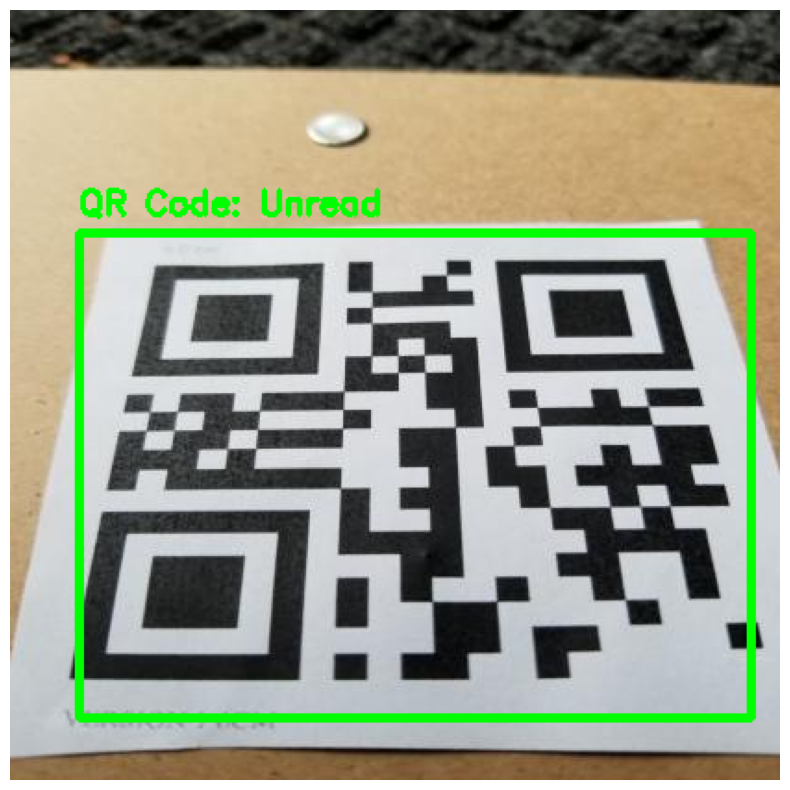

In [43]:
sample_image = os.path.join(images_dir, os.listdir(images_dir)[505])
run_test(sample_image, model, device)